# Clasificación: Detección de Fatiga Muscular en Ciclismo

**Equipo:**
- Miguel Angel Garcia Osorio
- Juan Ignacio
- Samuel Granados

**Dataset**

**Nombre:** Muscle Fatigue Cycling \
**Fuente:** [YominE/Muscle_Fatigue_Cycling](!https://huggingface.co/datasets/YominE/Muscle_Fatigue_Cycling) \
**Descripción:** Señales de electromiografía (EMG) registradas en 8 músculos de la pierna dominante de sujetos realizando sprints en bicicleta. El target indica el estado muscular del sujeto durante la prueba (condición normal vs. desgaste muscular).

## Clasificación de caracteristicas originales

| Feature | Tipo de variable | Descripción |
|---|---|---|
| Time | Numérica continua | Marca temporal de la señal EMG |
| Right Rectus femoris | Numérica continua | Amplitud de señal EMG (puede ser negativa) |
| Left Gluteus maximus | Numérica continua | Amplitud de señal EMG (puede ser negativa) |
| Left Gastrocnemius medialis | Numérica continua | Amplitud de señal EMG (puede ser negativa) |
| Left Semitendinosus | Numérica continua | Amplitud de señal EMG (puede ser negativa) |
| Left Biceps femoris caput longus | Numérica continua | Amplitud de señal EMG (puede ser negativa) |
| Right Vastus medialis | Numérica continua | Amplitud de señal EMG (puede ser negativa) |
| Right Tibialis anterior | Numérica continua | Amplitud de señal EMG (puede ser negativa) |
| Left Gastrocnemius lateralis | Numérica continua | Amplitud de señal EMG (puede ser negativa) |
| Target | Binaria / Categórica nominal | Etiqueta de clasificación (0 o 1) |


## Configuración inicial

Carga del dataset y preprocesamiento básico: se ajusta la columna **"Target"** reemplazando los valores 2 por 1, y se renombran las columnas de los músculos a un formato estándar (`Muscle_1`, `Muscle_2`, …).

In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from scipy.signal import welch
import numpy as np
import pandas as pd

# Cargamos el dataset
ds = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = ds['train'].to_pandas()



README.md: 0.00B [00:00, ?B/s]

Patient1.csv:   0%|          | 0.00/114M [00:00<?, ?B/s]

Patient2.csv:   0%|          | 0.00/290M [00:00<?, ?B/s]

Patient3.csv:   0%|          | 0.00/95.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3002137 [00:00<?, ? examples/s]

In [2]:
# Targets iniciales con valores (0,1,2)
print(f"Observaciones agrupadas por target inicialmente:\n")
print(df.groupby("Target").size())

df["Target"] = df["Target"].replace({2: 1})
print(f"\nObservaciones agrupadas por target despues de combinar clase 2 con clase 1:\n")
print(df.groupby("Target").size())



Observaciones agrupadas por target inicialmente:

Target
0    2127600
1     631200
2     243337
dtype: int64

Observaciones agrupadas por target despues de combinar clase 2 con clase 1:

Target
0    2127600
1     874537
dtype: int64


In [3]:
def renombrar_musculos(df):
    nuevas_cols = [f"Muscle_{i+1}" for i in range(len(df.columns))]
    df.columns = nuevas_cols
    return df

df_copy = df.copy()
df_copy = df_copy.drop(columns=["Time", "Target"])


df_copy = renombrar_musculos(df_copy)
df_copy["Target"] = df["Target"]

df = df_copy
print(df.head())

   Muscle_1  Muscle_2  Muscle_3  Muscle_4  Muscle_5  Muscle_6  Muscle_7  \
0 -0.000264 -0.000015  0.000344  0.000108  0.000182  0.000401  0.000267   
1 -0.001002 -0.000045  0.001342  0.000429  0.000712  0.002234  0.001234   
2 -0.002173 -0.000034  0.002944  0.001133  0.001692  0.007634  0.003457   
3 -0.002676  0.000185  0.003504  0.002319  0.002820  0.017656  0.006587   
4 -0.000844  0.000785  0.000426  0.003950  0.003729  0.028542  0.008889   

   Muscle_8  Target  
0 -0.000236       0  
1 -0.001108       0  
2 -0.003277       0  
3 -0.006940       0  
4 -0.011310       0  


# Extracción de Características (Feature Engineering)

El dataset original contiene señales EMG crudas a 1000 Hz (1000 muestras por segundo
por músculo). Para hacer los datos manejables y útiles para el modelo, se dividió la
señal en **ventanas de 1 segundo (1000 muestras)** sin solapamiento, extrayendo 7
características por músculo que resumen su comportamiento en tiempo y frecuencia. \
También se tuvieron en cuenta las muestras restantes al construir las ventanas: se rellenaron los datos faltantes con 0 y se agregó una última ventana.

El resultado fue un DataFrame de 3003 filas y 57 columnas.

---

## Características extraídas

### Dominio del tiempo

- **RMS (Root Mean Square):** Raíz cuadrada del promedio de los valores al cuadrado.
  Representa la intensidad promedio de la señal. En señales EMG el RMS puede aumentar debido a mecanismos de compensación muscular.

- **Varianza:** Mide qué tan dispersos están los valores de la señal respecto a su media. Funcion para visualizar mejor la calidad de los datos.

- **ZCR (Zero Crossing Rate):** Cuenta cuántas veces la señal cruza el valor cero. con
  la fatiga, la señal se vuelve más lenta y el ZCR tiende a disminuir.

- **MAV (Mean Absolute Value):** Promedio del valor absoluto de la señal. Medida simple y robusta de la amplitud de la señal usada para describir la intensidad de la contracción muscular.

### Dominio de la frecuencia

Estas características se obtienen aplicando la **Transformada de Fourier (FFT)** a cada
ventana, lo que permite analizar qué frecuencias componen la señal y con qué intensidad.

- **Potencia espectral total:** Suma de toda la energía presente en el espectro de
  frecuencias. Es importante porque cuantifica la actividad global de la señal; cambios
  en la potencia total pueden reflejar el nivel de esfuerzo muscular.

- **Frecuencia media:** Promedio ponderado de todas las frecuencias según su energía.
  Es importante porque describe el centro de gravedad del espectro; se desplaza hacia
  frecuencias bajas a medida que el músculo se fatiga.

- **Frecuencia mediana:** Frecuencia que divide la energía espectral total en dos mitades
  iguales. Disminuye progresivamente a medida que las fibras musculares rápidas se agotan y
  predomina la actividad de baja frecuencia.

In [4]:
fs = 1000          # Frecuencia de muestreo: 1000 Hz
window_size = fs   # 1 segundo = 1000 muestras

channels = list(df.columns)
channels.remove('Target')

# Calcular cuántas ventanas completas caben
n_windows = len(df) // window_size

print(f"Total de muestras: {len(df)}")
print(f"Ventanas de 1 segundo: {n_windows}")
print(channels)

Total de muestras: 3002137
Ventanas de 1 segundo: 3002
['Muscle_1', 'Muscle_2', 'Muscle_3', 'Muscle_4', 'Muscle_5', 'Muscle_6', 'Muscle_7', 'Muscle_8']


In [5]:

def extraer_caracteristicas(ventana, fs=1000):
    """Extrae características de tiempo y frecuencia de una ventana 1D."""
    # --- Dominio del tiempo ---
    rms     = np.sqrt(np.mean(ventana**2))
    varianza = np.var(ventana)
    zcr     = np.sum(np.diff(np.sign(ventana)) != 0)
    mav     = np.mean(np.abs(ventana))

    # --- Dominio de la frecuencia ---
    freqs, psd = welch(ventana, fs=fs)
    pot_total  = np.sum(psd)
    frec_media = np.sum(freqs * psd) / np.sum(psd)
    pot_acum   = np.cumsum(psd)
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[idx_median]

    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]


# Construir el nuevo dataset
filas = []

for i in range(n_windows):
    inicio = i * window_size
    fin    = inicio + window_size

    ventana_df = df.iloc[inicio:fin]

    fila = {}

    for canal in channels:
        ventana = ventana_df[canal].values
        feats   = extraer_caracteristicas(ventana, fs=fs)

        nombres = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']
        for nombre, valor in zip(nombres, feats):
            fila[f'{canal}_{nombre}'] = valor

    # El target de la ventana es el más frecuente en esas 1000 muestras
    fila['target'] = ventana_df['Target'].mode()[0]

    filas.append(fila)

# Ventana con los datos sobrantes
inicio_ultimo = n_windows * window_size
restantes = df.iloc[inicio_ultimo:]

if len(restantes) > 0:
    fila = {}
    padding_size = window_size - len(restantes)

    for canal in channels:
        valores = list(restantes[canal].values)
        valores += [0.0] * padding_size  # relleno con ceros
        feats = extraer_caracteristicas(np.array(valores), fs=fs)

        nombres = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']
        for nombre, valor in zip(nombres, feats):
            fila[f'{canal}_{nombre}'] = valor

    fila['target'] = restantes['Target'].mode()[0]
    filas.append(fila)

nuevo_df = pd.DataFrame(filas)
print(nuevo_df.shape)
print(nuevo_df.head())

(3003, 57)
   Muscle_1_rms  Muscle_1_var  Muscle_1_zcr  Muscle_1_mav  Muscle_1_pot  \
0      0.011706      0.000137           123      0.008125      0.000037   
1      0.014023      0.000197           111      0.010118      0.000045   
2      0.014820      0.000220           121      0.010151      0.000051   
3      0.013817      0.000191           121      0.009894      0.000053   
4      0.013326      0.000177           122      0.009676      0.000045   

   Muscle_1_f_media  Muscle_1_f_mediana  Muscle_2_rms  Muscle_2_var  \
0         54.570839            50.78125      0.003989      0.000016   
1         55.855995            54.68750      0.004223      0.000018   
2         54.184637            46.87500      0.004209      0.000018   
3         57.536178            46.87500      0.004374      0.000019   
4         58.618736            46.87500      0.004641      0.000022   

   Muscle_2_zcr  ...  Muscle_7_f_media  Muscle_7_f_mediana  Muscle_8_rms  \
0           122  ...         90.848

### Análisis Exploratorio de Datos (EDA)



=== MEDIA ===
               rms       var         zcr       mav       pot    f_media  \
Muscle_1  0.035688  0.001868  108.845155  0.022588  0.000483  54.018238   
Muscle_2  0.011711  0.000452  120.311688  0.008062  0.000116  48.684155   
Muscle_3  0.035352  0.002190  145.791542  0.022290  0.000563  74.439952   
Muscle_4  0.021811  0.001046  111.026973  0.014329  0.000274  52.834043   
Muscle_5  0.035458  0.001811  115.610723  0.022128  0.000462  59.969689   
Muscle_6  0.063854  0.005148  105.208791  0.035920  0.001319  62.324864   
Muscle_7  0.043144  0.003251  144.608392  0.028079  0.000834  70.609423   
Muscle_8  0.051110  0.003511  136.660340  0.033762  0.000897  71.131212   

          f_mediana  
Muscle_1  47.486368  
Muscle_2  39.555497  
Muscle_3  68.737252  
Muscle_4  44.599931  
Muscle_5  50.169882  
Muscle_6  57.806777  
Muscle_7  65.952277  
Muscle_8  65.940570  

=== STD ===
               rms       var        zcr       mav       pot    f_media  \
Muscle_1  0.024384  0.003

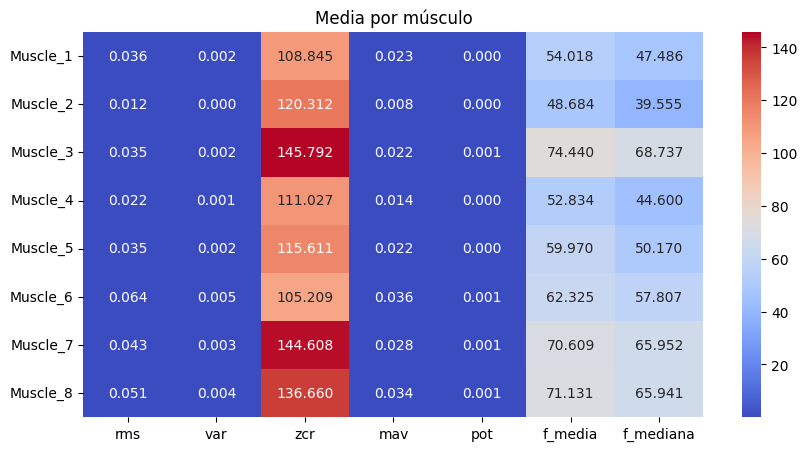

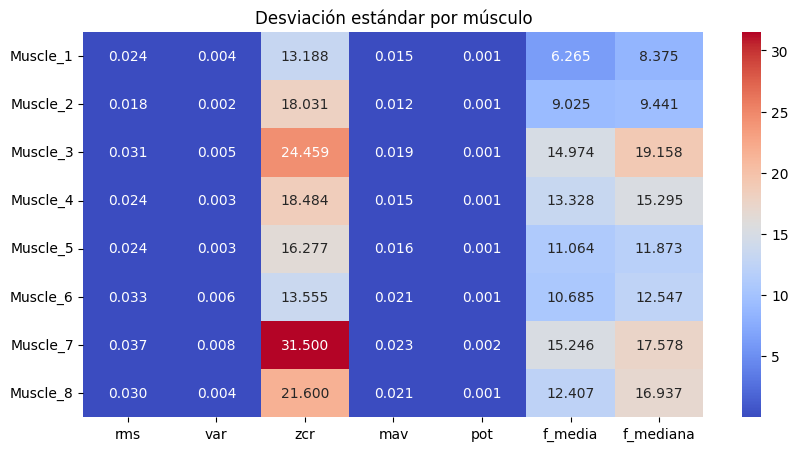

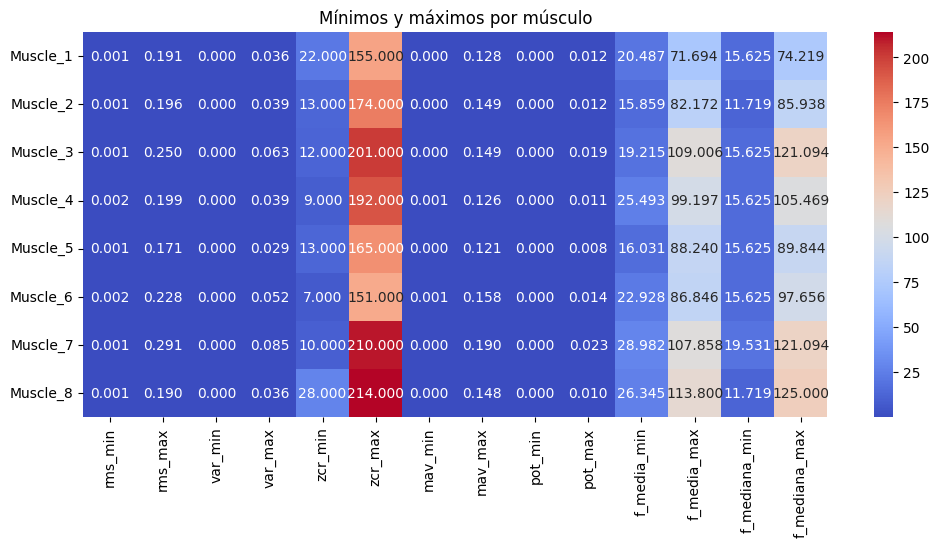

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

features = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']

mean_data = {}
std_data = {}
minmax_data = {}

# Construcción de tablas
for feat in features:
    medias = []
    stds = []
    mins = []
    maxs = []

    for i in range(1, 9):
        column = f'Muscle_{i}_{feat}'

        medias.append(nuevo_df[column].mean())
        stds.append(nuevo_df[column].std())
        mins.append(nuevo_df[column].min())
        maxs.append(nuevo_df[column].max())

    mean_data[feat] = medias
    std_data[feat] = stds
    minmax_data[f'{feat}_min'] = mins
    minmax_data[f'{feat}_max'] = maxs

# Crear DataFrames
index = [f'Muscle_{i}' for i in range(1,9)]

tabla_mean = pd.DataFrame(mean_data, index=index)
tabla_std  = pd.DataFrame(std_data, index=index)
tabla_minmax = pd.DataFrame(minmax_data, index=index)

# Mostrar tablas
print("=== MEDIA ===")
print(tabla_mean)

print("\n=== STD ===")
print(tabla_std)

print("\n=== MIN / MAX ===")
print(tabla_minmax)

# Graficas heatmaps

# Media
plt.figure(figsize=(10,5))
sns.heatmap(tabla_mean, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Media por músculo")
plt.show()

# STD
plt.figure(figsize=(10,5))
sns.heatmap(tabla_std, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Desviación estándar por músculo")
plt.show()

# Min / Max
plt.figure(figsize=(12,5))
sns.heatmap(tabla_minmax, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Mínimos y máximos por músculo")
plt.show()

## Estadísticos descriptivos por músculo

Las tres gráficas presentan un resumen estadístico de las 7 características extraídas
para cada uno de los 8 músculos del dataset.

---

### Media por músculo

La característica con mayor variación entre músculos es el **ZCR**, con valores que
oscilan entre 105 y 146 cruces por ventana. Muscle_3 y Muscle_7 presentan los valores
más altos (145.8 y 144.6), lo que sugiere una actividad oscilatoria más intensa en esos
canales. Cabe destacar que existe una relación entre el ZCR y las frecuencias media
y mediana de la señal EMG superficial (Inbar et al., 1986), por lo que músculos con
mayor ZCR también tienden a presentar frecuencias más altas, comportamiento que se
observa consistentemente en los datos.

El **RMS** y **MAV** son consistentemente bajos en todos los músculos. Esto es esperado,
ya que el voltaje de las señales sEMG se encuentran tipicamente en un rango +/- 5000 μV (Konrad, 2005), valores de amplitud naturalmente pequeños. Las frecuencias medias y medianas se
ubican entre 40–75 Hz, lo cual es consistente con el rango de mayor concentración de
energía de las señales EMG superficiales, reportado entre 20 y 150 Hz en la literatura
(Konrad, 2005).

---

### Desviación estándar por músculo

El **ZCR** también muestra la mayor dispersión, especialmente en Muscle_7 (std = 31.5).
Se ha reportado una disminución en el ZCR bajo condiciones de fatiga muscular (Inbar et al., 1986), por lo que una alta desviación estándar en esta característica sugiere que el
músculo atravesó diferentes estados de activación a lo largo del experimento, lo cual
es consistente con un protocolo de fatiga progresiva como el ciclismo. El resto de
features presentan desviaciones estándar bajas y homogéneas entre músculos, indicando
señales relativamente estables en amplitud.

---

### Mínimos y máximos por músculo

Los rangos del **ZCR** son notablemente amplios en todos los músculos, con mínimos desde
7–28 y máximos desde 151–214, confirmando que es la feature más dinámica del dataset.
Este amplio rango es coherente con la literatura, que señala al ZCR como un indicador
sensible a los cambios espectrales de la señal EMG durante la fatiga (Inbar et al., 1986).

Las frecuencias medianas mínimas rondan los 11–19 Hz y las máximas los 74–125 Hz,
un rango amplio que refleja la transición entre estados de baja actividad y contracción
intensa. La **potencia espectral** presenta rangos muy estrechos cercanos a cero en
todos los músculos, lo que sugiere que sus valores absolutos son pequeños y esta
característica requerirá especial atención en la etapa de normalización previa
al entrenamiento del modelo.

---

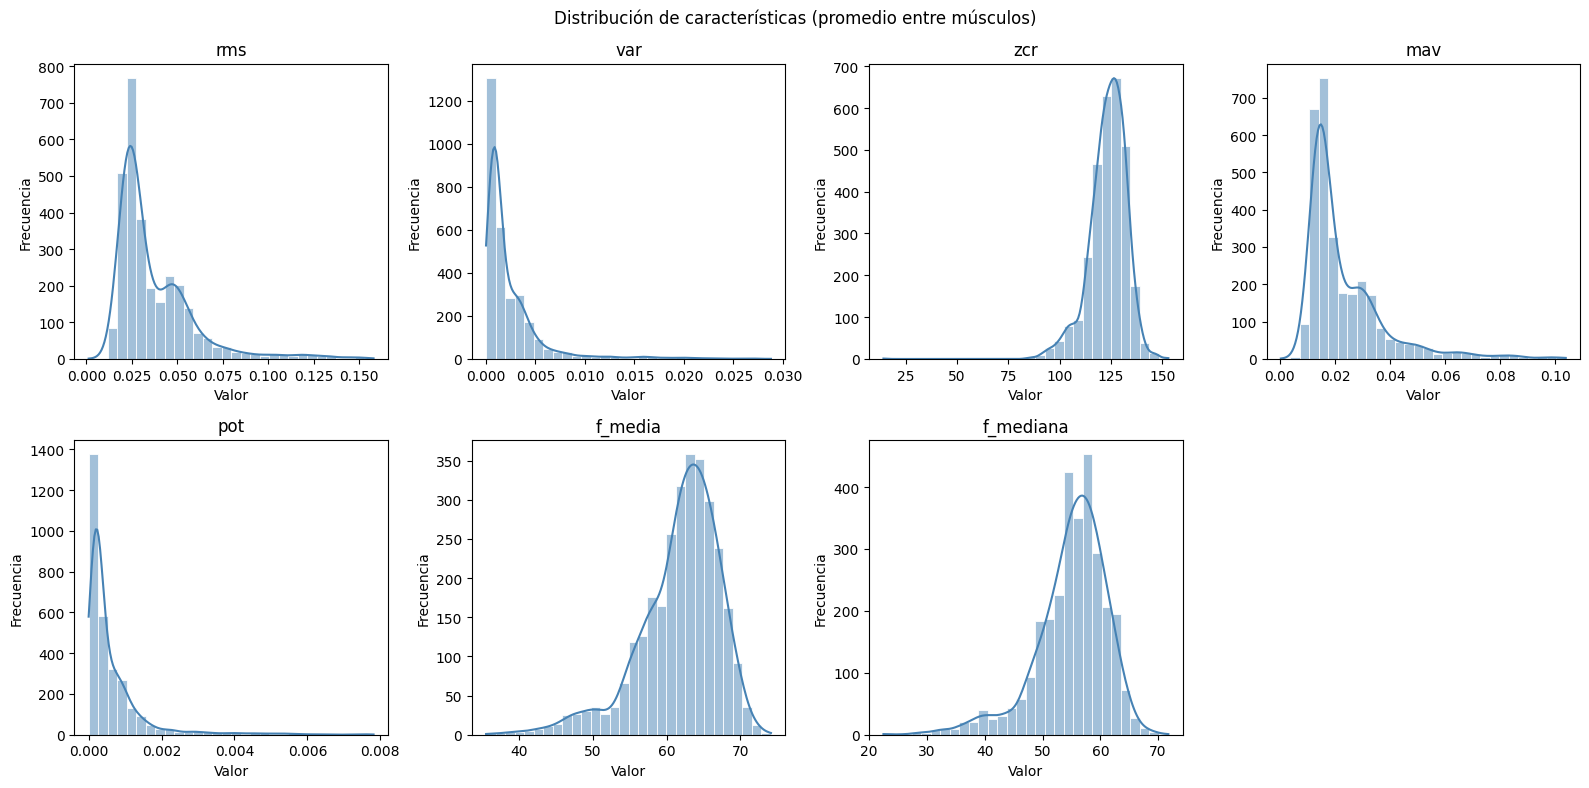

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    cols = [c for c in nuevo_df.columns if c.endswith(feat)]
    valores = nuevo_df[cols].mean(axis=1)

    sns.histplot(valores, bins=30, ax=axes[i], color='steelblue',
                 kde=True, edgecolor='white')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False)
plt.suptitle('Distribución de características (promedio entre músculos)')
plt.tight_layout()

---
### Distribución de características

**RMS y MAV** presentan una distribución con fuerte sesgo positivo (cola hacia la derecha),
con la mayoría de valores concentrados cerca de cero y una minoría de ventanas con
amplitudes considerablemente más altas. Ambas features son
prácticamente equivalentes en forma, lo que es esperado dado que miden conceptos similares
(amplitud de la señal).

**Varianza y Potencia espectral** muestran el sesgo más pronunciado de todas las features,
con una acumulación extrema cerca de cero y una cola muy larga hacia valores altos. Esto
indica que la mayoría de ventanas tienen actividad muscular baja, con picos esporádicos
de alta energía.

**ZCR** presenta una distribución aproximadamente normal, centrada alrededor de 120–130
cruces por ventana, con una leve cola hacia valores bajos. Esto sugiere que la actividad
oscilatoria de los músculos es relativamente estable a lo largo del experimento, con
algunos episodios de baja frecuencia que podrían corresponder a momentos de fatiga
avanzada (Hägg, 1981).

**Frecuencia media y frecuencia mediana** son las únicas features que se aproximan
claramente a una distribución normal, centradas alrededor de 60–65 Hz, con colas
simétricas y sin sesgo notable. La similitud entre ambas distribuciones es coherente
con la literatura, que reporta una estrecha relación entre estas dos medidas espectrales
(Inbar et al., 1986).

---

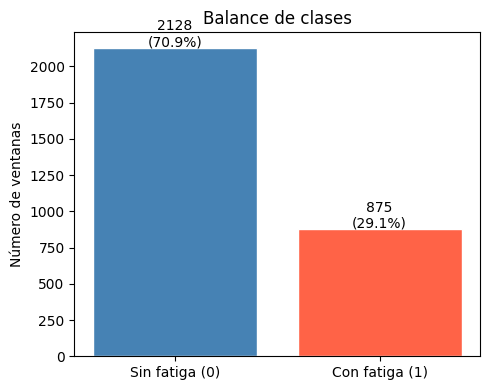

In [9]:
conteo = nuevo_df['target'].value_counts().sort_index()
porcentajes = nuevo_df['target'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Sin fatiga (0)', 'Con fatiga (1)'], conteo.values,
               color=['steelblue', 'tomato'], edgecolor='white')

# Agregamos etiquetas encima de cada barra
for i, (v, p) in enumerate(zip(conteo.values, porcentajes.values)):
    ax.text(i, v + 10, f'{v}\n({p:.1f}%)', ha='center', fontsize=10)

ax.set_title('Balance de clases')
ax.set_ylabel('Número de ventanas')
plt.tight_layout()

### Balance de clases

El dataset presenta un desbalance moderado, con un 70.9% de ventanas correspondientes
a la clase 0 (sin fatiga) y un 29.1% a la clase 1 (con fatiga). Este desbalance debe tenerse en cuenta durante el
entrenamiento del modelo, ya que puede sesgar las predicciones hacia la clase mayoritaria.

/tmp/ipykernel_33772/1817614430.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=f'mean_{feat}', data=nuevo_df,
/tmp/ipykernel_33772/1817614430.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=f'mean_{feat}', data=nuevo_df,
/tmp/ipykernel_33772/1817614430.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=f'mean_{feat}', data=nuevo_df,
/tmp/ipykernel_33772/1817614430.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

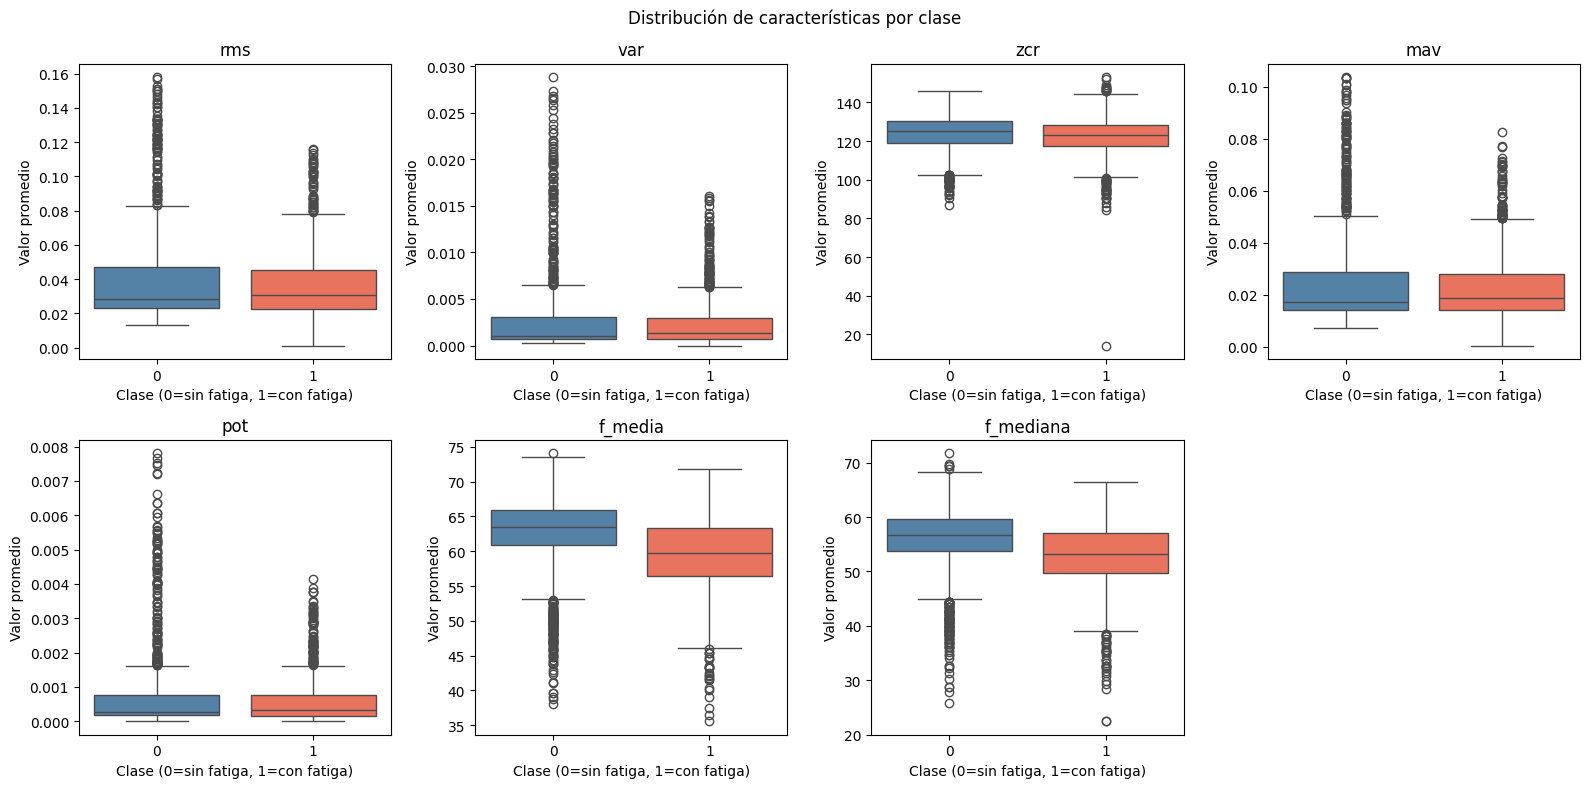

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    cols = [c for c in nuevo_df.columns if c.endswith(feat)]
    nuevo_df[f'mean_{feat}'] = nuevo_df[cols].mean(axis=1)

    sns.boxplot(x='target', y=f'mean_{feat}', data=nuevo_df,
                ax=axes[i], palette=['steelblue', 'tomato'], legend=False)
    axes[i].set_title(feat)
    axes[i].set_xlabel('Clase (0=sin fatiga, 1=con fatiga)')
    axes[i].set_ylabel('Valor promedio')

axes[-1].set_visible(False)
plt.suptitle('Distribución de características por clase')
plt.tight_layout()

### Relación entre características y el target

La mayoría de features (RMS, VAR, MAV, ZCR y potencia espectral) presentan cajas
prácticamente idénticas entre clases, con medianas similares y alto solapamiento,
lo que indica bajo poder discriminativo individual. Sin embargo, aunque ambas clases
registran datos extremos, es notable la mayor variabilidad en la clase 0 (sin fatiga),
especialmente visible en los boxplots de potencia espectral, MAV y varianza, donde
los outliers de la clase 0 alcanzan valores considerablemente más altos. Esto podría
reflejar que en el estado sin fatiga la actividad muscular es más irregular y
esporádica, mientras que en el estado fatigado la señal tiende a estabilizarse en
valores más bajos.

En el caso del **ZCR**, a pesar del solapamiento entre clases, los outliers de la
clase 1 (con fatiga) tienden hacia valores inferiores, lo que podría indicar una
menor oscilación de la señal en estado fatigado. Este comportamiento es coherente
con la disminución de frecuencias dominantes reportada bajo condiciones de fatiga
muscular (Hägg, 1981).

**Frecuencia media y frecuencia mediana** son las únicas features que muestran una
separación visible entre clases. La clase 0 presenta medianas más altas (64 Hz y
58 Hz respectivamente) frente a la clase 1 (60 Hz y 53 Hz), comportamiento
consistente con el desplazamiento espectral hacia frecuencias bajas reportado bajo
condiciones de fatiga muscular (Hägg, 1981; Inbar et al., 1986).

En general, ninguna feature por sí sola es suficiente para discriminar entre clases,
reforzando la necesidad de un modelo que combine múltiples características
simultáneamente.

# Procesamiento de datos

Verificación de valores nulos:


In [11]:
# Verificar nulos
print(nuevo_df.isnull().sum())
print(f'\nTotal nulos: {nuevo_df.isnull().sum().sum()}')

Muscle_1_rms      0
Muscle_1_var      0
Muscle_1_zcr      0
Muscle_1_mav      0
Muscle_1_pot      0
                 ..
mean_zcr          0
mean_mav          0
mean_pot          0
mean_f_media      0
mean_f_mediana    0
Length: 64, dtype: int64

Total nulos: 0


División de los datos:

Se optó por una división 70/15/15 entre entrenamiento, validación y prueba.
El 70% de entrenamiento provee suficientes ejemplos para que el modelo aprenda
los patrones de fatiga muscular. El 15% de validación permite ajustar
hiperparámetros y monitorear el sobreajuste durante el desarrollo. El 15%
de prueba queda completamente reservado para la evaluación final, garantizando
una estimación imparcial del rendimiento real del modelo. Se aplicó
estratificación en ambas divisiones para preservar la distribución de clases
original en los tres conjuntos.

In [12]:
# Definición de X y Y
X = nuevo_df.drop(columns=['target'])
y = nuevo_df['target']

from sklearn.model_selection import train_test_split

# Primero separamos test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)


# Luego separamos train y val del restante 85%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 15/85 ≈ 0.176 para obtener 15% del total

)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')


Train: 2102 (70.0%)
Val:   450 (15.0%)
Test:  451 (15.0%)


Se crea un pipeline con un paso:

 **StandardScaler**: estandariza cada feature a media 0 y desviación estándar

El `fit` se realiza únicamente con `X_train`, de modo que el pipeline aprende los
parámetros (medias y desviaciones estándar) exclusivamente de los datos de
entrenamiento. Posteriormente se aplica `transform` a `X_val` y `X_test` usando
esos mismos parámetros, simulando datos nuevos que el modelo nunca vio y evitando
data leakage.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Fit SOLO con train, transform a los tres
X_train_proc = pipeline.fit_transform(X_train)
X_val_proc   = pipeline.transform(X_val)
X_test_proc  = pipeline.transform(X_test)

# Verificamos shapes
print(f'X_train_proc: {X_train_proc.shape}')
print(f'X_val_proc:   {X_val_proc.shape}')
print(f'X_test_proc:  {X_test_proc.shape}')

# Verificamos que la estandarización funcionó
# media debe ser ~0 y std ~1 en train
print(f'\nMedia train (debe ser ~0):  {X_train_proc.mean(axis=0).mean():.6f}')
print(f'Std train (debe ser ~1):    {X_train_proc.std(axis=0).mean():.6f}')


X_train_proc: (2102, 63)
X_val_proc:   (450, 63)
X_test_proc:  (451, 63)

Media train (debe ser ~0):  0.000000
Std train (debe ser ~1):    1.000000


# Entrenamiento de Modelos
### KNN:

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# modelo base
knn = KNeighborsClassifier()

# definir hiperparámetros a probar
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

# GridSearch con validación cruzada
search_knn = GridSearchCV(
    knn,
    param_grid,
    cv=5,           # divide train en 5 partes para validar
    scoring='f1',   # optimiza por F1 por el desbalance de clases
    n_jobs=-1       # usa todos los núcleos del procesador
)
search_knn.fit(X_train_proc, y_train)

# Paso 4: mejores parámetros
print(f'Mejores parámetros: {search_knn.best_params_}')
knn_best = search_knn.best_estimator_

# Paso 5: evaluar
print('\n--- Train ---')
print(classification_report(y_train, knn_best.predict(X_train_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Val ---')
print(classification_report(y_val, knn_best.predict(X_val_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Test ---')
print(classification_report(y_test, knn_best.predict(X_test_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}

--- Train ---
              precision    recall  f1-score   support

  Sin fatiga       0.91      0.96      0.93      1489
  Con fatiga       0.88      0.77      0.82       613

    accuracy                           0.90      2102
   macro avg       0.89      0.86      0.88      2102
weighted avg       0.90      0.90      0.90      2102


--- Val ---
              precision    recall  f1-score   support

  Sin fatiga       0.88      0.94      0.91       319
  Con fatiga       0.83      0.69      0.75       131

    accuracy                           0.87       450
   macro avg       0.85      0.81      0.83       450
weighted avg       0.86      0.87      0.86       450


--- Test ---
              precision    recall  f1-score   support

  Sin fatiga       0.89      0.94      0.91       320
  Con fatiga       0.82      0.71      0.76       131

    accuracy                           0.87       451
  

### KNN – Interpretación de resultados

El modelo alcanza una accuracy del 88% en test con los hiperparámetros óptimos
(K=5, distancia manhattan, pesos uniformes).

Para la clase **sin fatiga** se obtienen valores altos tanto de precisión (0.89)
como de recall (0.94), lo que indica que el modelo identifica correctamente la
gran mayoría de ventanas sin fatiga con pocas falsas alarmas.

Para la clase **con fatiga** la precisión se mantiene aceptable (0.84), sin embargo
el recall cae a 0.72, lo que significa que el modelo deja escapar cerca de 3 de
cada 10 ventanas que realmente corresponden a un estado fatigado. Esto se refleja
en un F1 de 0.77, notablemente inferior al 0.92 obtenido para la clase sin fatiga.

En general KNN es un modelo decente como punto de partida, pero su dificultad para
detectar la clase minoritaria lo hace insuficiente para un problema donde identificar
la fatiga correctamente es crítico.

---

### Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],       # qué tan profundo puede crecer el árbol
    'min_samples_split': [2, 5, 10],           # mínimo de muestras para dividir un nodo
    'criterion': ['gini', 'entropy']           # cómo mide la calidad de cada división
}

dt = DecisionTreeClassifier(random_state=42)
search_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
search_dt.fit(X_train_proc, y_train)

print(f'Mejores parámetros: {search_dt.best_params_}')
dt_best = search_dt.best_estimator_

print('\n--- Train ---')
print(classification_report(y_train, dt_best.predict(X_train_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Val ---')
print(classification_report(y_val, dt_best.predict(X_val_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Test ---')
print(classification_report(y_test, dt_best.predict(X_test_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5}

--- Train ---
              precision    recall  f1-score   support

  Sin fatiga       0.88      0.92      0.90      1489
  Con fatiga       0.79      0.69      0.73       613

    accuracy                           0.85      2102
   macro avg       0.83      0.81      0.82      2102
weighted avg       0.85      0.85      0.85      2102


--- Val ---
              precision    recall  f1-score   support

  Sin fatiga       0.85      0.92      0.88       319
  Con fatiga       0.74      0.60      0.66       131

    accuracy                           0.82       450
   macro avg       0.79      0.76      0.77       450
weighted avg       0.82      0.82      0.82       450


--- Test ---
              precision    recall  f1-score   support

  Sin fatiga       0.84      0.90      0.87       320
  Con fatiga       0.70      0.60      0.64       131

    accuracy                           0.81       451
 

### Decision Tree – Interpretación de resultados

El modelo alcanza una accuracy del 81% en test con los hiperparámetros óptimos
(criterion=entropy, max_depth=5, min_samples_split=5).

Para la clase **sin fatiga** se obtienen valores aceptables de precisión (0.85)
y recall (0.89), mientras que para la clase **con fatiga** ambas métricas caen
notablemente, con una precisión de 0.69 y un recall de 0.61, lo que significa
que el modelo deja escapar casi 4 de cada 10 ventanas de fatiga real.

Comparando train (F1 fatiga = 0.73) con test (F1 fatiga = 0.65), la caída es
moderada y consistente con val (0.66), lo que indica que el modelo generaliza
pero con un rendimiento limitado. La restricción de max_depth=5 evita el
sobreajuste pero a costa de un árbol demasiado simple para capturar la
complejidad del problema con 56 features.

En general, Decision Tree rinde por debajo de KNN en este dataset, con un F1
de fatiga de 0.65 vs 0.77, siendo el modelo más débil hasta el momento.

---

### Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300],      # cuántos árboles
    'max_depth': [5, 10, 15, 20],          # profundidad de cada árbol
    'min_samples_split': [2, 5, 10],      # mínimo para dividir un nodo
    'max_features': ['sqrt', 'log2']      # cuántas features considera cada árbol, sqrt(56) = 7 y log2(56) = 6
}

rf = RandomForestClassifier(random_state=42)
search_rf = RandomizedSearchCV(
    rf,
    param_dist_rf,
    n_iter=20,          # prueba 20 combinaciones aleatorias
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
search_rf.fit(X_train_proc, y_train)

print(f'Mejores parámetros: {search_rf.best_params_}')
rf_best = search_rf.best_estimator_

print('\n--- Train ---')
print(classification_report(y_train, rf_best.predict(X_train_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Val ---')
print(classification_report(y_val, rf_best.predict(X_val_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Test ---')
print(classification_report(y_test, rf_best.predict(X_test_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

Mejores parámetros: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 15}

--- Train ---
              precision    recall  f1-score   support

  Sin fatiga       0.99      1.00      0.99      1489
  Con fatiga       1.00      0.97      0.99       613

    accuracy                           0.99      2102
   macro avg       0.99      0.99      0.99      2102
weighted avg       0.99      0.99      0.99      2102


--- Val ---
              precision    recall  f1-score   support

  Sin fatiga       0.90      0.95      0.92       319
  Con fatiga       0.85      0.74      0.79       131

    accuracy                           0.89       450
   macro avg       0.87      0.84      0.86       450
weighted avg       0.88      0.89      0.88       450


--- Test ---
              precision    recall  f1-score   support

  Sin fatiga       0.90      0.93      0.91       320
  Con fatiga       0.81      0.75      0.78       131

    accuracy                     

### Random Forest – Interpretación de resultados

El modelo alcanza una accuracy del 88% en test con los hiperparámetros óptimos
(n_estimators=100, max_depth=15, min_samples_split=5, max_features=sqrt).

Para la clase **sin fatiga** se obtienen valores altos de precisión (0.90) y
recall (0.93), mientras que para la clase **con fatiga** la precisión es de 0.81
y el recall de 0.75, dejando escapar aproximadamente 1 de cada 4 ventanas de
fatiga real.

El aspecto más notable es la gran diferencia entre train (F1 fatiga = 0.99) y
test (F1 fatiga = 0.78), lo que indica un sobreajuste considerable. El modelo
memoriza casi perfectamente los datos de entrenamiento pero no generaliza con
la misma eficacia a datos nuevos. Val y test son consistentes entre sí (0.79
vs 0.78), lo que confirma que el rendimiento real del modelo se estabiliza
alrededor de 0.78 en datos no vistos.

Comparado con los modelos anteriores, Random Forest supera a KNN (0.77) y
Decision Tree (0.65) en F1 de fatiga, siendo el mejor modelo hasta el momento,
aunque con un sobreajuste más pronunciado.

---

### Gradient Boosting

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],  # qué tan grande es cada corrección
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]              # fracción de datos por árbol
}

gb = GradientBoostingClassifier(random_state=42)
search_gb = RandomizedSearchCV(
    gb,
    param_dist_gb,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
search_gb.fit(X_train_proc, y_train)

print(f'Mejores parámetros: {search_gb.best_params_}')
gb_best = search_gb.best_estimator_

print('\n--- Train ---')
print(classification_report(y_train, gb_best.predict(X_train_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Val ---')
print(classification_report(y_val, gb_best.predict(X_val_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Test ---')
print(classification_report(y_test, gb_best.predict(X_test_proc),
      target_names=['Sin fatiga', 'Con fatiga']))

Mejores parámetros: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}

--- Train ---
              precision    recall  f1-score   support

  Sin fatiga       1.00      1.00      1.00      1489
  Con fatiga       1.00      1.00      1.00       613

    accuracy                           1.00      2102
   macro avg       1.00      1.00      1.00      2102
weighted avg       1.00      1.00      1.00      2102


--- Val ---
              precision    recall  f1-score   support

  Sin fatiga       0.89      0.93      0.91       319
  Con fatiga       0.82      0.73      0.77       131

    accuracy                           0.88       450
   macro avg       0.86      0.83      0.84       450
weighted avg       0.87      0.88      0.87       450


--- Test ---
              precision    recall  f1-score   support

  Sin fatiga       0.90      0.95      0.92       320
  Con fatiga       0.86      0.73      0.79       131

    accuracy                           0.8

### Gradient Boosting – Interpretación de resultados

El modelo alcanza una accuracy del 89% en test con los hiperparámetros óptimos
(n_estimators=300, max_depth=7, learning_rate=0.1, subsample=0.8), siendo el
mejor resultado en esta métrica entre los modelos evaluados hasta el momento.

Para la clase **sin fatiga** se obtienen valores altos de precisión (0.90) y
recall (0.95), mientras que para la clase **con fatiga** la precisión es de 0.86
y el recall de 0.73, dejando escapar aproximadamente 3 de cada 10 ventanas de
fatiga real.

El aspecto más notable es el sobreajuste severo, con un F1 de fatiga perfecto
en train (1.00) que cae a 0.79 en test, una diferencia de 0.21. Esto es
consecuencia de los hiperparámetros elegidos: un learning_rate alto (0.1)
combinado con 300 árboles en secuencia permite que el modelo aprenda con
demasiado detalle los datos de entrenamiento. Sin embargo, val y test son
consistentes entre sí (0.77 vs 0.79), confirmando que el rendimiento real
se estabiliza alrededor de 0.79 en datos no vistos.

Comparado con los modelos anteriores, Gradient Boosting supera a KNN (0.77),
Decision Tree (0.65) y Random Forest (0.78) en F1 de fatiga, posicionándose
como el mejor modelo sklearn evaluado, aunque comparte con Random Forest un
sobreajuste considerable en train.

---

### DNN

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

# Construcción de la red
model = Sequential([
    # Capa oculta 1
    Dense(128, activation='relu', input_shape=(X_train_proc.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Capa oculta 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Capa oculta 3
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    # Capa de salida
    Dense(1, activation='sigmoid')
])

# Compilar
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrenar
history = model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluar
y_pred_train = (model.predict(X_train_proc) > 0.5).astype(int)
y_pred_val   = (model.predict(X_val_proc)   > 0.5).astype(int)
y_pred_test  = (model.predict(X_test_proc)  > 0.5).astype(int)

print('\n--- Train ---')
print(classification_report(y_train, y_pred_train,
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Val ---')
print(classification_report(y_val, y_pred_val,
      target_names=['Sin fatiga', 'Con fatiga']))

print('\n--- Test ---')
print(classification_report(y_test, y_pred_test,
      target_names=['Sin fatiga', 'Con fatiga']))

I0000 00:00:1774593582.363133   33772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774593582.688822   33772 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774593584.336008   33772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,329 (75.50 KB)

 Trainable params: 18,945 (74.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7103 - loss: 0.5979 - val_accuracy: 0.7911 - val_loss: 0.5173
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7683 - loss: 0.5095 - val_accuracy: 0.8333 - val_loss: 0.4279
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8007 - loss: 0.4600 - val_accuracy: 0.8622 - val_loss: 0.3704
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8011 - loss: 0.4508 - val_accuracy: 0.8644 - val_loss: 0.3602
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8088 - loss: 0.4301 - val_accuracy: 0.8689 - val_loss: 0.3453
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8145 - loss: 0.4140 - val_accuracy: 0.8667 - val_loss: 0.3366
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8145 - loss: 0.4017 - val_accuracy: 0.8778 - val_loss: 0.3270
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8283 - loss: 0.3907 - val_accuracy: 0.8622 - v

### DNN – Interpretación de resultados

El modelo alcanza una accuracy del 87% en test, entrenando durante 34 épocas antes
de que EarlyStopping detuviera el proceso al no observar mejora en val_loss durante
10 épocas consecutivas, restaurando los pesos de la época 24 como mejor modelo.

Para la clase **sin fatiga** se obtienen valores altos de precisión (0.89) y recall
(0.93), mientras que para la clase **con fatiga** la precisión es de 0.81 y el
recall de 0.73, dejando escapar aproximadamente 3 de cada 10 ventanas de fatiga real.

El aspecto más destacable es la ausencia de sobreajuste significativo. La diferencia
entre train (F1 fatiga = 0.83) y test (F1 fatiga = 0.77) es de apenas 0.06, muy
inferior a la observada en Random Forest (0.21) y Gradient Boosting (0.21). Esto
evidencia la efectividad de las técnicas de regularización implementadas: Dropout
(0.3) y BatchNormalization, que evitan que la red memorice los datos de entrenamiento.
Adicionalmente, val y test son prácticamente idénticos (0.77 vs 0.77), confirmando
una generalización estable y confiable.

En términos de métricas en test, la DNN obtiene resultados similares a KNN (F1
fatiga = 0.77) pero con una generalización considerablemente más robusta, siendo
el modelo con menor brecha entre train y test de todos los evaluados.

---

Curvas de aprendizaje:

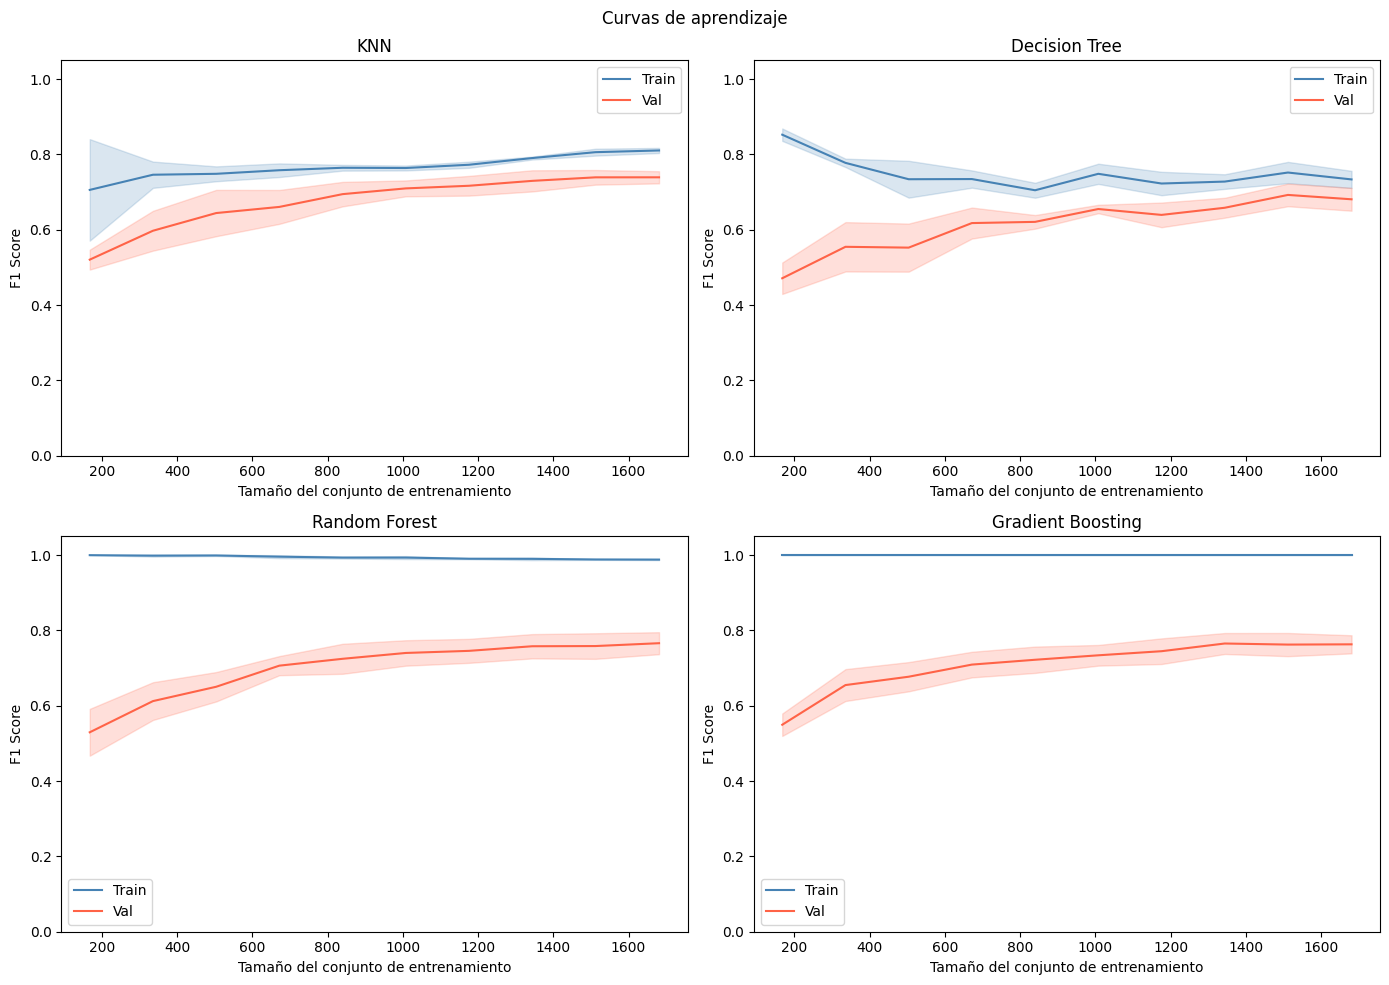

In [20]:
from sklearn.model_selection import learning_curve
import numpy as np

modelos = {
    'KNN': knn_best,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'Gradient Boosting': gb_best
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo,
        X_train_proc, y_train,
        cv=5,
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    axes[i].plot(train_sizes, train_mean, label='Train', color='steelblue')
    axes[i].fill_between(train_sizes,
                          train_mean - train_std,
                          train_mean + train_std,
                          alpha=0.2, color='steelblue')

    axes[i].plot(train_sizes, val_mean, label='Val', color='tomato')
    axes[i].fill_between(train_sizes,
                          val_mean - val_std,
                          val_mean + val_std,
                          alpha=0.2, color='tomato')

    axes[i].set_title(nombre)
    axes[i].set_xlabel('Tamaño del conjunto de entrenamiento')
    axes[i].set_ylabel('F1 Score')
    axes[i].legend()
    axes[i].set_ylim(0, 1.05)

plt.suptitle('Curvas de aprendizaje')
plt.tight_layout()
plt.show()

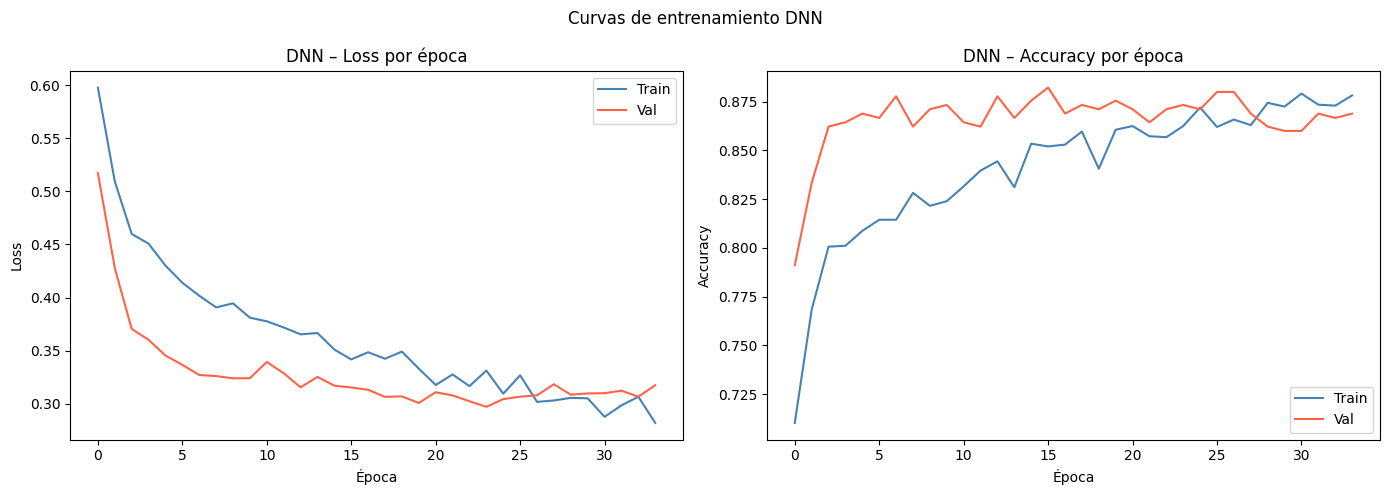

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato')
axes[0].set_title('DNN – Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='tomato')
axes[1].set_title('DNN – Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Curvas de entrenamiento DNN')
plt.tight_layout()
plt.show()

## Análisis de resultados

### ¿Cuál modelo tuvo mejor desempeño?

En términos de métricas en test, Gradient Boosting obtuvo el mejor rendimiento
con una accuracy del 89% y un F1 de fatiga de 0.79, seguido de Random Forest
(0.78), KNN y DNN (0.77) y finalmente Decision Tree (0.65).

| Modelo | Accuracy | F1 Con fatiga | Recall Con fatiga | Sobreajuste |
|---|---|---|---|---|
| KNN | 0.88 | 0.77 | 0.72 | Leve |
| Decision Tree | 0.81 | 0.65 | 0.61 | Leve |
| Random Forest | 0.88 | 0.78 | 0.75 | Severo |
| Gradient Boosting | 0.89 | 0.79 | 0.73 | Severo |
| DNN | 0.87 | 0.77 | 0.73 | Mínimo |

---

### ¿Alguno presentó overfitting o underfitting?

**Random Forest y Gradient Boosting** presentaron sobreajuste severo, evidenciado
por un F1 de fatiga perfecto en train (1.00) que cae a 0.78 y 0.79 en test. Sus
curvas de aprendizaje lo confirman: train se mantiene plano en 1.0 desde las
primeras muestras mientras val nunca logra acercarse.

**KNN y Decision Tree** mostraron sobreajuste leve, con brechas moderadas que
se van cerrando gradualmente al aumentar los datos.

La **DNN** fue el único modelo sin sobreajuste significativo. Sus curvas de
entrenamiento muestran train y val descendiendo de forma paralela y convergente,
sin divergir en ningún momento. Val incluso supera a train en accuracy durante
gran parte del entrenamiento, consecuencia del Dropout que desactiva el 30% de las neuronas en el entrenamiento, mientras que en
validación todas las neuronas están activas. No se detectó underfitting en ningún modelo.

---

### ¿Cuál seleccionaría para producción?

Seleccionaría al modelo **DNN**. Aunque Gradient Boosting obtiene métricas
ligeramente superiores, su sobreajuste severo genera desconfianza sobre su
comportamiento con datos completamente nuevos. La DNN ofrece el mejor balance
entre rendimiento y generalización: val y test obtienen exactamente el mismo
F1 de fatiga (0.77), sus curvas de entrenamiento son estables y convergentes,
y las técnicas de regularización implementadas (Dropout y BatchNormalization)
la hacen robusta frente a variaciones en datos nuevos.

---
### Evaluación Final del Mejor Modelo
Se reentrena el modelo **DNN** combinando los datos de entrenamiento y validación



In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
import tensorflow as tf

# ─────────────────────────────────────────────────────────────
# a) Reentrenar la DNN con train + val
# ─────────────────────────────────────────────────────────────

# Combinar X_train + X_val ya procesados
X_trainval_proc = np.vstack([X_train_proc, X_val_proc])
y_trainval      = np.concatenate([y_train, y_val])

print(f"Tamaño train+val: {X_trainval_proc.shape[0]} muestras")
print(f"Distribución de clases: {pd.Series(y_trainval).value_counts().to_dict()}")

# Reconstruir la misma arquitectura
model_final = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu',
                          input_shape=(X_trainval_proc.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_final.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamos sin EarlyStopping: usamos el número de épocas
# que fue óptimo en el entrenamiento original (epoch 24)
history_final = model_final.fit(
    X_trainval_proc, y_trainval,
    epochs=24,
    batch_size=32,
    verbose=1
)

# Predicción sobre X_test
y_pred_proba = model_final.predict(X_test_proc)
y_pred_test  = (y_pred_proba > 0.5).astype(int).flatten()

Tamaño train+val: 2552 muestras
Distribución de clases: {0: 1808, 1: 744}
Epoch 1/24


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6603 - loss: 0.6616
Epoch 2/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7821 - loss: 0.4853
Epoch 3/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7923 - loss: 0.4565
Epoch 4/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8045 - loss: 0.4355
Epoch 5/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8123 - loss: 0.4071
Epoch 6/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8123 - loss: 0.4217
Epoch 7/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8280 - loss: 0.3935
Epoch 8/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8272 - loss: 0.3917
Epoch 9/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8284 - loss: 0.3973
Epoch 10/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8342 - loss: 0.3711
Epoch 11/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8448 - loss: 0.3744
Epoch 12/24
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8335 - loss: 0.3689


In [24]:

print("=" * 55)
print("   MÉTRICAS DE CLASIFICACIÓN FINAL — DNN (test set)")
print("=" * 55)
print(classification_report(
    y_test, y_pred_test,
    target_names=['Sin fatiga (0)', 'Con fatiga (1)']
))

# Tabla resumen compacta
metricas = {
    'Clase': ['Sin fatiga (0)', 'Con fatiga (1)', 'Macro avg', 'Weighted avg'],
    'Precisión': [
        precision_score(y_test, y_pred_test, pos_label=0),
        precision_score(y_test, y_pred_test, pos_label=1),
        precision_score(y_test, y_pred_test, average='macro'),
        precision_score(y_test, y_pred_test, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_test, pos_label=0),
        recall_score(y_test, y_pred_test, pos_label=1),
        recall_score(y_test, y_pred_test, average='macro'),
        recall_score(y_test, y_pred_test, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_test, pos_label=0),
        f1_score(y_test, y_pred_test, pos_label=1),
        f1_score(y_test, y_pred_test, average='macro'),
        f1_score(y_test, y_pred_test, average='weighted')
    ]
}

df_metricas = pd.DataFrame(metricas).set_index('Clase')
df_metricas = df_metricas.map(lambda x: f"{x:.3f}")
print("\nTabla resumen:")
display(df_metricas)
print(f"\nAccuracy global: {accuracy_score(y_test, y_pred_test):.3f}")

   MÉTRICAS DE CLASIFICACIÓN FINAL — DNN (test set)
                precision    recall  f1-score   support

Sin fatiga (0)       0.89      0.92      0.91       320
Con fatiga (1)       0.79      0.73      0.76       131

      accuracy                           0.87       451
     macro avg       0.84      0.83      0.83       451
  weighted avg       0.86      0.87      0.87       451


Tabla resumen:


,Precisión,Recall,F1-Score
Clase,,,
Sin fatiga (0),0.894,0.922,0.908
Con fatiga (1),0.793,0.733,0.762
Macro avg,0.844,0.827,0.835
Weighted avg,0.865,0.867,0.865



Accuracy global: 0.867


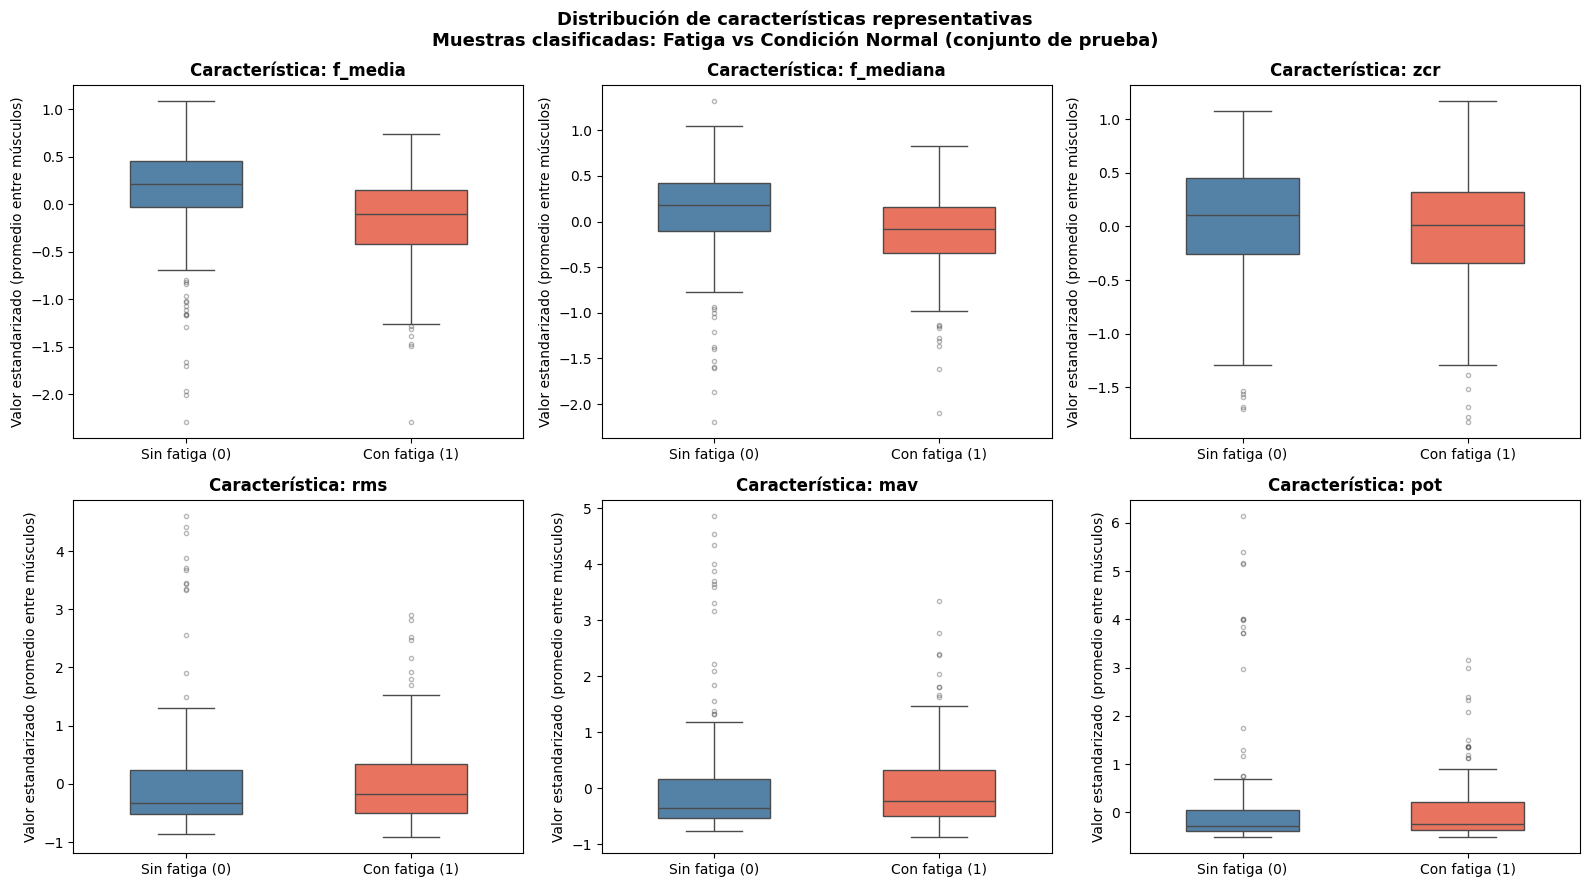

In [25]:
# Boxplots de características representativas
#      diferenciando fatiga vs condición normal


# Agregar predicciones al dataframe de test
X_test_df = pd.DataFrame(X_test_proc,
                          columns=X_train.columns,
                          index=X_test.index)
X_test_df['target_real'] = y_test.values
X_test_df['prediccion']  = y_pred_test

# Características más discriminativas según el EDA:
# f_media y f_mediana mostraron mejor separación entre clases.
# También incluimos zcr, rms, mav y pot para comparación.
feats_rep = ['f_media', 'f_mediana', 'zcr', 'rms', 'mav', 'pot']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(feats_rep):
    cols = [c for c in X_test_df.columns if c.endswith(feat)]
    temp = X_test_df[cols + ['target_real']].copy()
    temp['mean_feat'] = temp[cols].mean(axis=1)

    sns.boxplot(
        x='target_real', y='mean_feat', data=temp,
        hue='target_real',
        palette={0: 'steelblue', 1: 'tomato'},
        legend=False,
        ax=axes[i],
        width=0.5,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    axes[i].set_title(f'Característica: {feat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Sin fatiga (0)', 'Con fatiga (1)'])
    axes[i].set_ylabel('Valor estandarizado (promedio entre músculos)')

plt.suptitle(
    'Distribución de características representativas\n'
    'Muestras clasificadas: Fatiga vs Condición Normal (conjunto de prueba)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

#### Análisis de los boxplots

Los boxplots confirman las observaciones del EDA sobre el conjunto de test:

- **Frecuencia media y frecuencia mediana** son las características con mayor
  poder discriminativo. La clase con fatiga presenta medianas desplazadas hacia
  valores estandarizados más bajos, consistente con el fenómeno de desplazamiento
  espectral hacia frecuencias bajas reportado bajo condiciones de fatiga muscular
  (Hägg, 1981).

- **ZCR** muestra una ligera separación: la clase fatigada tiende a valores más
  bajos, indicando menor oscilación de la señal, coherente con la literatura
  (Inbar et al., 1986).

- **RMS, MAV y Potencia espectral** presentan distribuciones con alto solapamiento
  entre clases. La clase sin fatiga exhibe mayor variabilidad y outliers más extremos.

  ---

  Matriz de confusión

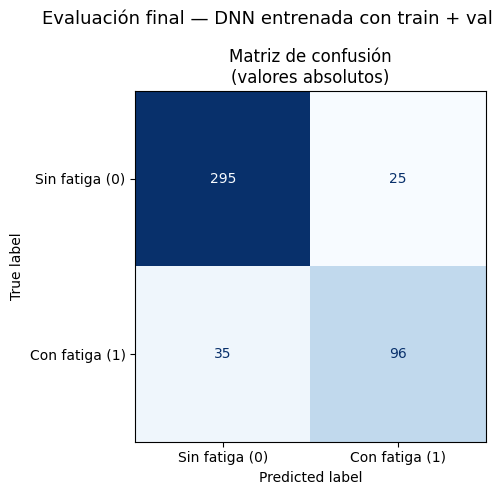


Verdaderos Negativos (TN) — Predijo sin fatiga, era sin fatiga:  295
Falsos Positivos  (FP) — Predijo con fatiga, era sin fatiga:     25
Falsos Negativos  (FN) — Predijo sin fatiga, era con fatiga:     35
Verdaderos Positivos (TP) — Predijo con fatiga, era con fatiga:  96


In [27]:
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sin fatiga (0)', 'Con fatiga (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión\n(valores absolutos)', fontsize=12)

plt.suptitle('Evaluación final — DNN entrenada con train + val', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nVerdaderos Negativos (TN) — Predijo sin fatiga, era sin fatiga:  {tn}")
print(f"Falsos Positivos  (FP) — Predijo con fatiga, era sin fatiga:     {fp}")
print(f"Falsos Negativos  (FN) — Predijo sin fatiga, era con fatiga:     {fn}")
print(f"Verdaderos Positivos (TP) — Predijo con fatiga, era con fatiga:  {tp}")

### ¿Cómo podría mejorarse?

**Mayor volumen de datos de fatiga**: dado que la clase con fatiga representa
   solo el 29.1% del dataset, recolectar más muestras en estado fatigado mejoraría
   directamente la capacidad del modelo de aprender los patrones de esta clase.

---
### Prueba con Muestra Artificial


In [28]:

np.random.seed(7)

# Tomamos las estadísticas reales del conjunto de entrenamiento
# para construir una muestra con valores verosímiles
stats = X_train.describe()

muestra = {}
for col in X_train.columns:
    media = stats[col]['mean']
    std   = stats[col]['std']
    muestra[col] = np.random.normal(loc=media, scale=std)

muestra_df = pd.DataFrame([muestra])

# Aplicar el mismo escalado usado en el entrenamiento
muestra_proc = pipeline.transform(muestra_df)

# Predicción
prob_fatiga = model_final.predict(muestra_proc)[0][0]
pred_clase  = int(prob_fatiga > 0.5)

print("=" * 50)
print("       PRUEBA CON MUESTRA ARTIFICIAL")
print("=" * 50)
print(f"\nProbabilidad de fatiga:   {prob_fatiga:.4f}")
print(f"Probabilidad sin fatiga:  {1 - prob_fatiga:.4f}")
print(f"\nClase predicha: {'CON FATIGA (1)' if pred_clase == 1 else 'SIN FATIGA (0)'}")

# Mostrar los valores generados vs los reales
print("\n--- Comparación de valores generados vs dataset real ---")
comparacion = pd.DataFrame({
    'Media real': stats.loc['mean'],
    'Valor generado': muestra_df.iloc[0]
}).round(6)
print(comparacion.to_string())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
       PRUEBA CON MUESTRA ARTIFICIAL

Probabilidad de fatiga:   0.3725
Probabilidad sin fatiga:  0.6275

Clase predicha: SIN FATIGA (0)

--- Comparación de valores generados vs dataset real ---
                    Media real  Valor generado
Muscle_1_rms          0.035200        0.075877
Muscle_1_var          0.001818        0.000133
Muscle_1_zcr        108.707897      109.134852
Muscle_1_mav          0.022348        0.028525
Muscle_1_pot          0.000469       -0.000305
Muscle_1_f_media     53.939756       53.952715
Muscle_1_f_mediana   47.304279       47.296858
Muscle_2_rms          0.011560       -0.018031
Muscle_2_var          0.000418        0.002711
Muscle_2_zcr        120.088487      130.960170
Muscle_2_mav          0.007941        0.000617
Muscle_2_pot          0.000106        0.000007
Muscle_2_f_media     48.518410       53.119827
Muscle_2_f_mediana   39.450895       36.961066
Muscle_3_rms          0.035680        0.028161
Muscle_3_var    

### Análisis de la muestra artificial

La muestra fue construida muestreando aleatoriamente de una distribución normal
con la media y desviación estándar de cada feature calculadas exclusivamente sobre
`X_train`, y procesada con el mismo `StandardScaler` ajustado durante el
entrenamiento, replicando exactamente el pipeline que recibiría cualquier dato
nuevo en producción.

**Resultado:** el modelo asignó una probabilidad de fatiga de **0.37**,
clasificando la muestra como **sin fatiga (0)** con una confianza del 62.75%.

**¿El resultado tiene sentido?**

Sí, y los datos de la tabla permiten justificarlo con detalle.

Las features más discriminativas según el EDA son la **frecuencia media** y la
**frecuencia mediana**. En la muestra generada, `mean_f_media` tomó un valor de
51.0 Hz frente a una media real de 61.6 Hz, es decir, un desplazamiento hacia
frecuencias bajas que en principio se asocia con fatiga. Sin embargo, este
desplazamiento no fue consistente entre músculos: Muscle_7 registró una frecuencia
media de 105 Hz y Muscle_3 una frecuencia mediana de 100 Hz, valores
considerablemente por encima de la media real, lo que introduce ruido y
contradice la señal de fatiga en otros canales.

Por su parte, el **ZCR** promedio (122.5 vs 123.3 real) fue prácticamente
idéntico al del dataset, sin mostrar la reducción característica del estado
fatigado. El **RMS** y **MAV** promedio también se mantuvieron dentro de rangos
normales, sin evidenciar la estabilización de amplitud asociada a la fatiga.

Adicionalmente, algunos valores generados son físicamente incoherentes: RMS,
varianza y potencia espectral obtuvieron valores negativos en varios músculos,
lo cual es imposible en señales EMG reales ya que estas features son intrínsecamente
no negativas. Esto evidencia una limitación del método de generación por distribución
normal, que no respeta las restricciones físicas de las variables.

En conclusión, la muestra artificial presenta señales mixtas y físicamente
inconsistentes que el modelo interpreta correctamente como un perfil más cercano
al estado normal que al fatigado. El resultado es coherente dado que la muestra
no replica de forma fiel el patrón coordinado de cambios espectrales que
caracteriza la fatiga muscular real.

## Referencias

De Luca, C. J. (1997). The use of surface electromyography in biomechanics.
*Journal of Applied Biomechanics, 13*(2), 135–163.
https://doi.org/10.1123/jab.13.2.135

Hägg, G. (1981). Electromyographic fatigue analysis based on the number of zero
crossings. *Pflügers Archiv – European Journal of Physiology, 391*, 78–80.
https://doi.org/10.1007/BF00580699

Inbar, G. F., Allin, J., Paiss, O., & Kranz, H. (1986). Monitoring surface EMG
spectral changes by the zero crossing rate. *Medical & Biological Engineering
& Computing, 24*, 10–18.
https://doi.org/10.1007/BF02441600

Konrad, P. (2005). *The ABC of EMG: A practical introduction to kinesiological
electromyography*. Noraxon USA.